In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [2]:
data = fetch_california_housing()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train, temp = train_test_split(df, test_size=0.30, random_state=42)


In [8]:
val, test = train_test_split(temp, test_size=0.50, random_state=42)


In [9]:
print("Train size:", train.shape)
print("Validation size:", val.shape)
print("Test size:", test.shape)


Train size: (14448, 9)
Validation size: (3096, 9)
Test size: (3096, 9)


In [10]:
# TRAIN
X_train = train.drop("MedHouseVal", axis=1)
y_train = train["MedHouseVal"]

# VALIDATION
X_val = val.drop("MedHouseVal", axis=1)
y_val = val["MedHouseVal"]

# TEST
X_test = test.drop("MedHouseVal", axis=1)
y_test = test["MedHouseVal"]


In [11]:
# ===== CREATE CLASSIFICATION LABELS (CORRECT WAY) =====

y_train_class, bins = pd.qcut(y_train, 3, labels=[0,1,2], retbins=True)

y_val_class = pd.cut(y_val, bins=bins, labels=[0,1,2], include_lowest=True)
y_test_class = pd.cut(y_test, bins=bins, labels=[0,1,2], include_lowest=True)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [13]:
train.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

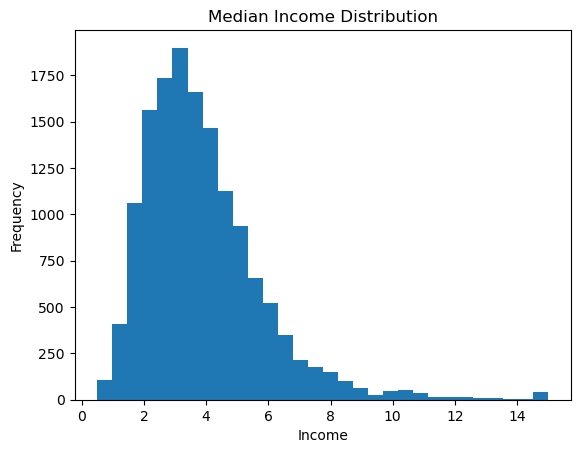

In [14]:
import matplotlib.pyplot as plt

plt.hist(train["MedInc"], bins=30)
plt.title("Median Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()


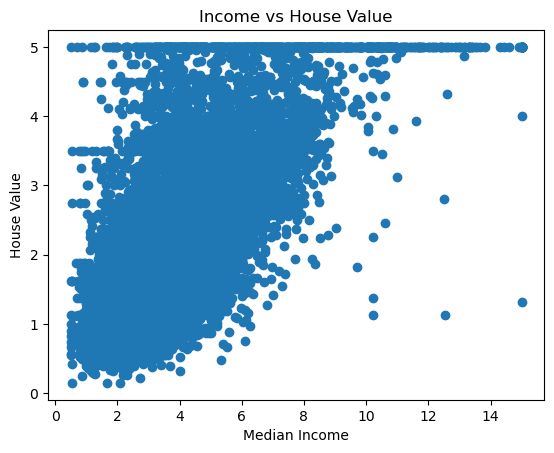

In [15]:
plt.scatter(train["MedInc"], train["MedHouseVal"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Value")
plt.show()


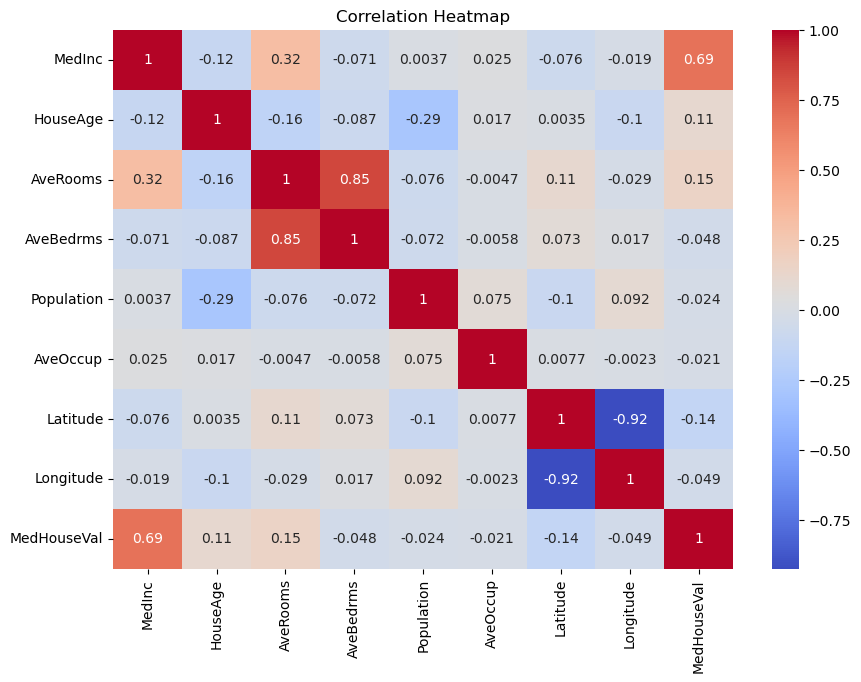

In [16]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [17]:
from sklearn.linear_model import LinearRegression


In [18]:
simple_model = LinearRegression()

# Using only MedInc column
simple_model.fit(X_train_scaled[:, [0]], y_train)


LinearRegression()

In [19]:
simple_pred = simple_model.predict(X_test_scaled[:, [0]])


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

print("Simple Regression MSE:", mean_squared_error(y_test, simple_pred))
print("Simple Regression R2:", r2_score(y_test, simple_pred))


Simple Regression MSE: 0.6608572198292422
Simple Regression R2: 0.5002253561465753


In [21]:
multi_model = LinearRegression()

multi_model.fit(X_train_scaled, y_train)


LinearRegression()

In [22]:
multi_pred = multi_model.predict(X_test_scaled)


In [23]:
print("Multiple Regression MSE:", mean_squared_error(y_test, multi_pred))
print("Multiple Regression R2:", r2_score(y_test, multi_pred))


Multiple Regression MSE: 0.5202604958440162
Multiple Regression R2: 0.6065519204153755


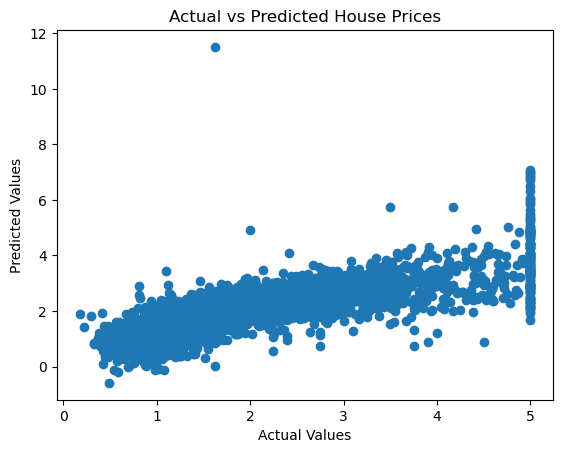

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, multi_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [25]:
from sklearn.model_selection import train_test_split

train_c, temp_c = train_test_split(df, test_size=0.30, random_state=42)
val_c, test_c = train_test_split(temp_c, test_size=0.50, random_state=42)


In [26]:
# ===== CLASSIFICATION DATA (CORRECT) =====

X_train_c = X_train_scaled
X_val_c = X_val_scaled
X_test_c = X_test_scaled

y_train_c = y_train_class
y_val_c = y_val_class
y_test_c = y_test_class

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_c = scaler.fit_transform(X_train_c)
X_val_c = scaler.transform(X_val_c)
X_test_c = scaler.transform(X_test_c)


In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

log_pred = log_model.predict(X_test_c)


In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_c, y_train_c)

dt_pred = dt_model.predict(X_test_c)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_c, y_train_c)

rf_pred = rf_model.predict(X_test_c)


In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test_c, rf_pred))

print(confusion_matrix(y_test_c, rf_pred))

print(classification_report(y_test_c, rf_pred))


Random Forest Accuracy: 0.8165374677002584
[[890 133  11]
 [131 756 133]
 [ 21 139 882]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1034
           1       0.74      0.74      0.74      1020
           2       0.86      0.85      0.85      1042

    accuracy                           0.82      3096
   macro avg       0.82      0.82      0.82      3096
weighted avg       0.82      0.82      0.82      3096



In [32]:
from sklearn.svm import SVC


In [33]:
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_c, y_train_c)


SVC()

In [34]:
svm_pred = svm_model.predict(X_test_c)


In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("SVM Accuracy:", accuracy_score(y_test_c, svm_pred))

print(confusion_matrix(y_test_c, svm_pred))

print(classification_report(y_test_c, svm_pred))


SVM Accuracy: 0.7571059431524548
[[827 198   9]
 [148 714 158]
 [ 19 220 803]]
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1034
           1       0.63      0.70      0.66      1020
           2       0.83      0.77      0.80      1042

    accuracy                           0.76      3096
   macro avg       0.76      0.76      0.76      3096
weighted avg       0.76      0.76      0.76      3096



In [36]:
print("Random Forest Accuracy:", accuracy_score(y_test_c, rf_pred))


Random Forest Accuracy: 0.8165374677002584


In [37]:
from sklearn.neural_network import MLPClassifier


In [38]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=300,
    random_state=42
)


In [39]:
nn_model.fit(X_train_c, y_train_c)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(32,), max_iter=300, random_state=42)

In [40]:
nn_pred = nn_model.predict(X_test_c)


In [41]:
from sklearn.metrics import accuracy_score, classification_report

print("Neural Network Accuracy:", accuracy_score(y_test_c, nn_pred))
print(classification_report(y_test_c, nn_pred))


Neural Network Accuracy: 0.7739018087855297
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1034
           1       0.65      0.72      0.69      1020
           2       0.84      0.79      0.82      1042

    accuracy                           0.77      3096
   macro avg       0.78      0.77      0.78      3096
weighted avg       0.78      0.77      0.78      3096



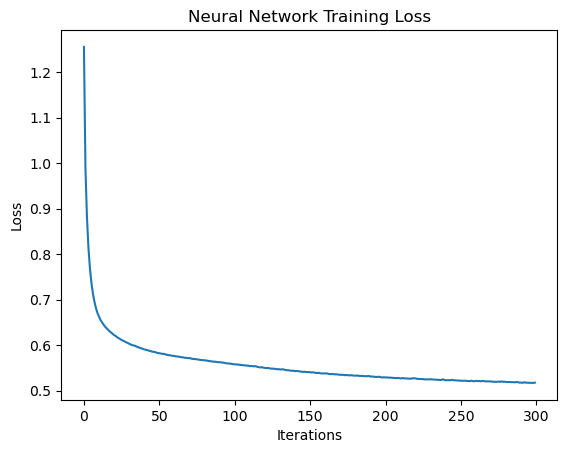

In [42]:
import matplotlib.pyplot as plt

plt.plot(nn_model.loss_curve_)
plt.title("Neural Network Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


In [53]:
pickle.dump(multi_model, open("model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

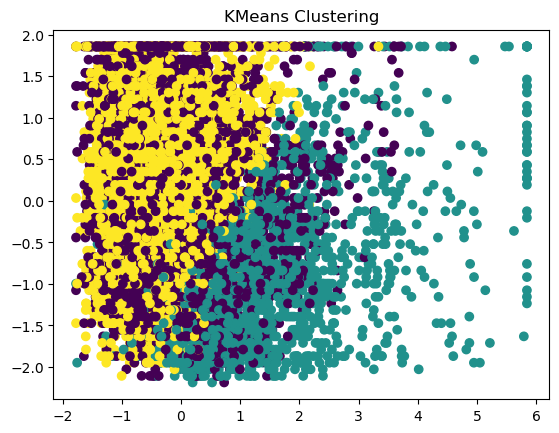

In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=clusters)
plt.title("KMeans Clustering")
plt.show()

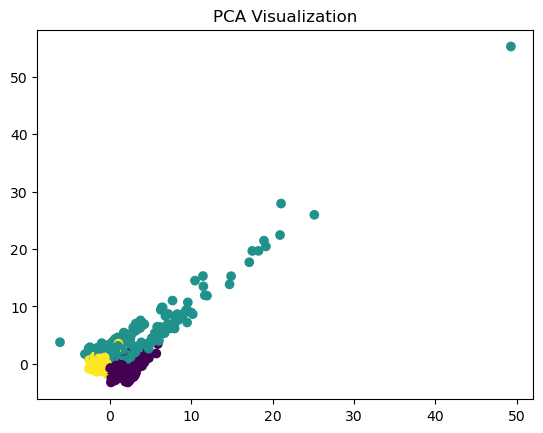

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("PCA Visualization")
plt.show()